In [60]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Literal

In [61]:
class QuadState(TypedDict):
    a:int
    b:int
    c:int

    equation:str
    discrimant:float
    results:str
    

In [62]:
def show_equation(state: QuadState):
    equation=f"{state['a']}x² + {state['b']}x + {state['c']}"

    return {'equation': equation}
    


In [63]:
def calculate_discrimant(state: QuadState):
    discrimant=state['b']**2-(4*state['a']*state['c'])

    return {'discrimant':discrimant}


In [64]:
def real_root(state:QuadState):
    root1=(-state['b']+(state['discrimant']**0.5))/(2*state['a'])
    root2=(-state['b']-(state['discrimant']**0.5))/(2*state['a'])
    return {'results':f"real roots: {root1} and {root2}"}

In [66]:
def imaginary_root(state:QuadState):
  
    return {'results':'no real roots '}

In [67]:
def repeated_root(state:QuadState):
    root1=(-state['b']+(state['discrimant']**0.5))/(2*state['a'])
    root2=(-state['b']-(state['discrimant']**0.5))/(2*state['a'])
    return {'results':f"euqal are roots: {root1} and {root2}"}

In [68]:
def check_condition(state: QuadState)-> Literal["real_root","repeated_root","imaginary_root"]:
    if state['discrimant']>0:
        return "real_root"
    elif state['discrimant']<0:
        return "imaginary_root"
    else:
        return "repeated_root"

In [70]:
graph=StateGraph(QuadState)

In [71]:


graph.add_node('show_equation',show_equation)
graph.add_node('calculate_discrimant',calculate_discrimant)
graph.add_node('real_root',real_root)
graph.add_node('imaginary_root',imaginary_root)
graph.add_node('repeated_root',repeated_root)



In [72]:
graph.add_edge(START, 'show_equation')
graph.add_edge('show_equation','calculate_discrimant')
graph.add_conditional_edges('calculate_discrimant',check_condition)
graph.add_edge('real_root',END)
graph.add_edge('repeated_root',END)
graph.add_edge('imaginary_root',END)

In [73]:
workflow=graph.compile()


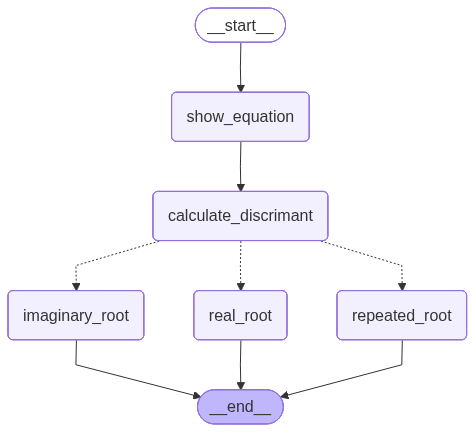

In [39]:
workflow

In [74]:
initial_state={
    'a':4,
    'b':-5,
    'c':-4

}

workflow.invoke(initial_state)

{'a': 4,
 'b': -5,
 'c': -4,
 'equation': '4x² + -5x + -4',
 'discrimant': 89,
 'results': 'real roots: 1.8042476415070754 and -0.5542476415070754'}